# Expectativa de vida global (2016-2025)

## 1. Preparacao

In [1]:
from pathlib import Path
import re
import unicodedata
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from scipy.stats import mannwhitneyu

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.base import clone
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample

In [2]:
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
DATA_PATH = DATA_DIR / "expectativa_vida_2016_2025.csv"

if not DATA_PATH.exists():
    DATA_PATH = PROJECT_DIR / "expectativa_vida_2016_2025.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError("Arquivo expectativa_vida_2016_2025.csv nao encontrado.")

print("Pasta do projeto:", PROJECT_DIR)
print("Arquivo de dados:", DATA_PATH)

Pasta do projeto: /home/jota/digital_college/py03/PY03_EngenhariaDeIA/aula18/atividade_Aula/life_expectancy_project
Arquivo de dados: /home/jota/digital_college/py03/PY03_EngenhariaDeIA/aula18/atividade_Aula/life_expectancy_project/data/expectativa_vida_2016_2025.csv


## 2. Carga e primeira inspecao

In [3]:
df_raw = pd.read_csv(DATA_PATH)

shape_info = pd.DataFrame({
    "metrica": ["linhas", "colunas"],
    "valor": [df_raw.shape[0], df_raw.shape[1]],
})

In [4]:
display(shape_info)

,metrica,valor
0,linhas,1945
1,colunas,22


In [5]:
display(df_raw.head())

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2016,Developing,65.04,260,61,0.07,91.140,64.040,1155,19.12,82,6.410,8.21,66.530,0.100,765.23,34225634,16.980,17.200,0.41,10.03
1,Afghanistan,2017,Developing,66.98,259,61,0.04,113.060,66.540,1146,19.33,83,6.920,8.05,65.840,0.060,931.11,34832494,16.690,17.370,0.44,9.93
2,Afghanistan,2018,Developing,68.02,253,60,0.05,133.260,67.860,1152,19.53,84,7.370,8,65.530,0.010,1118.09,35204149,16.980,17.180,0.42,9.95
3,Afghanistan,2019,Developing,68.12,248,58,0.17,151.630,67.360,1133,19.12,83,7.690,8.12,66.100,0.000,1309.56,35817726,17.080,16.970,0.4,9.91
4,Afghanistan,2020,Developing,69.27,244,57,0.23,169.990,67.560,1097,18.91,82,8.140,8.28,66.480,0.000,1492.86,36143541,16.720,16.600,0.39,10.01


In [6]:
display(df_raw.dtypes.rename("tipo").to_frame())

,tipo
Country,str
Year,str
Status,str
Life expectancy,str
Adult Mortality,int64
infant deaths,int64
Alcohol,str
percentage expenditure,float64
Hepatitis B,float64
Measles,int64


In [7]:
missing_report = (
    df_raw.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
    .assign(missing_pct=lambda x: 100 * x["missing_count"] / len(df_raw))
    .query("missing_count > 0")
    .sort_values("missing_pct", ascending=False)
)

status_report = df_raw["Status"].value_counts(dropna=False).rename_axis("status_original").to_frame("count")
negative_adult_mortality = pd.to_numeric(df_raw["Adult Mortality"], errors="coerce").lt(0).sum()

quality_report = pd.DataFrame({
    "checagem": ["duplicatas", "adult_mortality_negativa", "paises_com_espaco_extra"],
    "valor": [
        int(df_raw.duplicated().sum()),
        int(negative_adult_mortality),
        int(df_raw["Country"].astype("string").str.match(r"^\s|\s$").sum()),
    ],
})

display(missing_report)

,missing_count,missing_pct
GDP,22,1.131
Income composition of resources,21,1.080
Alcohol,21,1.080
Schooling,12,0.617
Total expenditure,12,0.617
Hepatitis B,10,0.514
Population,9,0.463
Life expectancy,8,0.411
BMI,6,0.308


In [8]:
display(status_report)

,count
status_original,
Developing,1579
Developed,316
Developing,18
DEVELOPING,18
developing,9
DEVELOPED,3
Developed,1
developed,1


In [9]:
display(quality_report)

,checagem,valor
0,duplicatas,15
1,adult_mortality_negativa,4
2,paises_com_espaco_extra,50


A inspecao acima mostra tres pontos para tratar antes da modelagem: ausencias pontuais, variacoes de escrita em `Status` e alguns valores invalidos em mortalidade adulta. O arquivo tambem tem duplicatas, entao a limpeza precisa remover linhas repetidas antes de salvar a base tratada.

## 3. Limpeza dos dados

In [10]:
def clean_column_name(name):
    name = unicodedata.normalize("NFKD", name).encode("ascii", "ignore").decode("ascii")
    name = name.strip().lower()
    name = re.sub(r"\s+", "_", name)
    name = re.sub(r"[^a-z0-9_]", "", name)
    name = re.sub(r"_+", "_", name).strip("_")
    return name


def parse_number(series):
    values = series.astype("string").str.strip()
    values = values.str.replace(r"(?<=\d),(?=\d{3}(?:[,\s]|$))", "", regex=True)
    values = values.str.replace(",", ".", regex=False)
    return pd.to_numeric(values, errors="coerce")


def fill_numeric_by_group(data, column):
    data[column] = data.groupby("country")[column].transform(lambda x: x.fillna(x.median()))
    data[column] = data.groupby("status")[column].transform(lambda x: x.fillna(x.median()))
    data[column] = data[column].fillna(data[column].median())
    return data

In [11]:
df_clean = df_raw.copy()
df_clean.columns = [clean_column_name(col) for col in df_clean.columns]

df_clean["country"] = df_clean["country"].astype("string").str.strip()
df_clean["status"] = df_clean["status"].astype("string").str.strip().str.title()
df_clean = df_clean[df_clean["status"].isin(["Developed", "Developing"])].copy()

for col in df_clean.columns.drop(["country", "status"]):
    df_clean[col] = parse_number(df_clean[col])

duplicates_removed = int(df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

non_negative_cols = [
    "life_expectancy", "adult_mortality", "infant_deaths", "alcohol",
    "percentage_expenditure", "measles", "bmi", "underfive_deaths",
    "total_expenditure", "hivaids", "gdp", "population",
    "thinness_119_years", "thinness_59_years", "schooling",
]

for col in non_negative_cols:
    df_clean.loc[df_clean[col] < 0, col] = np.nan

valid_ranges = {
    "life_expectancy": (35, 100),
    "year": (2016, 2025),
    "bmi": (5, 80),
    "income_composition_of_resources": (0, 1),
}

for col, (lower, upper) in valid_ranges.items():
    df_clean.loc[~df_clean[col].between(lower, upper), col] = np.nan

for col in ["hepatitis_b", "polio", "diphtheria"]:
    df_clean.loc[~df_clean[col].between(0, 100), col] = np.nan

missing_before = int(df_clean.isna().sum().sum())

for col in df_clean.select_dtypes(include="number").columns:
    df_clean = fill_numeric_by_group(df_clean, col)

for col in ["year", "adult_mortality", "infant_deaths", "measles", "underfive_deaths"]:
    df_clean[col] = df_clean[col].round().astype(int)

clean_path = PROJECT_DIR / "data" / "df_clean.csv"
clean_path.parent.mkdir(exist_ok=True)
df_clean.to_csv(clean_path, index=False)

clean_summary = pd.DataFrame({
    "metrica": ["linhas_finais", "colunas", "duplicatas_removidas", "missings_antes_imputacao", "missings_finais"],
    "valor": [df_clean.shape[0], df_clean.shape[1], duplicates_removed, missing_before, int(df_clean.isna().sum().sum())],
})

display(clean_summary)
display(df_clean["status"].value_counts().rename_axis("status").to_frame("count"))
print("Base limpa salva em:", clean_path)

,metrica,valor
0,linhas_finais,1930
1,colunas,22
2,duplicatas_removidas,15
3,missings_antes_imputacao,198
4,missings_finais,0


,count
status,
Developing,1610
Developed,320


Base limpa salva em: /home/jota/digital_college/py03/PY03_EngenhariaDeIA/aula18/atividade_Aula/life_expectancy_project/data/df_clean.csv


A tabela de resumo confirma que a base ficou sem valores ausentes no final. Como `Status` passou a ter apenas as duas categorias esperadas, a base limpa ja pode ser usada na EDA e na modelagem.

## 4. EDA apos limpeza

In [12]:
target_summary = df_clean["life_expectancy"].describe().to_frame("life_expectancy")
target_skew = df_clean["life_expectancy"].skew()

status_groups = [
    df_clean.loc[df_clean["status"] == "Developed", "life_expectancy"],
    df_clean.loc[df_clean["status"] == "Developing", "life_expectancy"],
]
mann_stat, mann_pvalue = mannwhitneyu(status_groups[0], status_groups[1], alternative="two-sided")

skewness = (
    df_clean.select_dtypes(include="number")
    .drop(columns=["year"], errors="ignore")
    .skew()
    .sort_values(key=lambda x: x.abs(), ascending=False)
    .head(10)
    .to_frame("skewness")
)

eda_results = pd.DataFrame({
    "metrica": ["skew_life_expectancy", "mannwhitney_statistic", "mannwhitney_pvalue"],
    "valor": [target_skew, mann_stat, mann_pvalue],
})

display(target_summary)


,life_expectancy
count,"1,930.000"
mean,72.668
std,8.281
min,50.780
25%,67.480
50%,73.745
75%,78.670
max,90.000


In [13]:
display(eda_results)

,metrica,valor
0,skew_life_expectancy,-0.377
1,mannwhitney_statistic,"466,143.500"
2,mannwhitney_pvalue,0.000


In [14]:
display(skewness)

,skewness
gdp,26.764
measles,9.182
infant_deaths,8.179
underfive_deaths,7.790
population,7.112
percentage_expenditure,4.806
hivaids,3.532
diphtheria,-2.380
adult_mortality,2.226
polio,-2.209


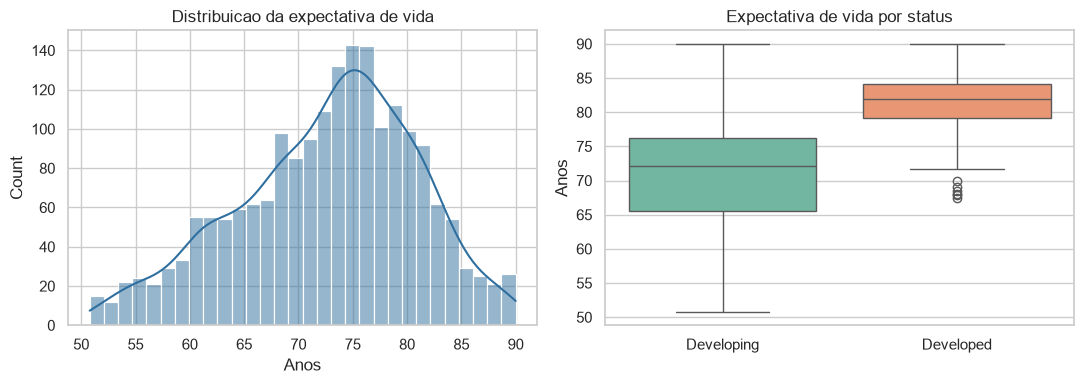

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df_clean["life_expectancy"], bins=30, kde=True, ax=axes[0], color="#2f6f9f")
axes[0].set_title("Distribuicao da expectativa de vida")
axes[0].set_xlabel("Anos")

sns.boxplot(data=df_clean, x="status", y="life_expectancy", ax=axes[1], palette="Set2")
axes[1].set_title("Expectativa de vida por status")
axes[1].set_xlabel("")
axes[1].set_ylabel("Anos")

plt.tight_layout()
plt.show()

Pelos resultados acima, a variavel-alvo nao esta perfeitamente simetrica e os grupos `Developed` e `Developing` apresentam diferenca estatistica pelo teste de Mann-Whitney. A tabela de skewness tambem mostra por que faz sentido aplicar transformacao logaritmica em variaveis muito assimetricas, como `gdp`, `measles` e `population`.

Obs:

* O teste Mann-Whitney U é usado para comparar dois grupos independentes quando você quer saber se eles têm distribuições diferentes, sem assumir que os dados seguem distribuição normal.
* Ele é uma alternativa não paramétrica ao teste t. Em vez de comparar diretamente médias assumindo normalidade, ele trabalha com os ranks dos valores. Ou seja, ele ordena todas as expectativas de vida e verifica se os valores de um grupo tendem a ficar sistematicamente acima ou abaixo dos valores do outro.
* No notebook, o p-value deu  ~0.00. Isso indica que a diferença entre os grupos é estatisticamente significativa.

In [16]:
year_trend = df_clean.groupby("year", as_index=False)["life_expectancy"].mean()
top_countries = (
    df_clean.groupby("country")["life_expectancy"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .to_frame("life_expectancy_mean")
)
display(year_trend)

,year,life_expectancy
0,2016,71.807
1,2017,72.040
2,2018,72.272
3,2019,72.385
4,2020,72.656
5,2021,72.729
6,2022,72.945
7,2023,73.159
8,2024,73.246
9,2025,73.437


In [17]:
# Ranking de países por expectativa de vida média
display(top_countries)

,life_expectancy_mean
country,
Denmark,89.425
Slovenia,88.627
Cyprus,88.215
Chile,86.798
Costa Rica,86.592
Spain,86.445
Iceland,86.359
Finland,85.920
Japan,85.283


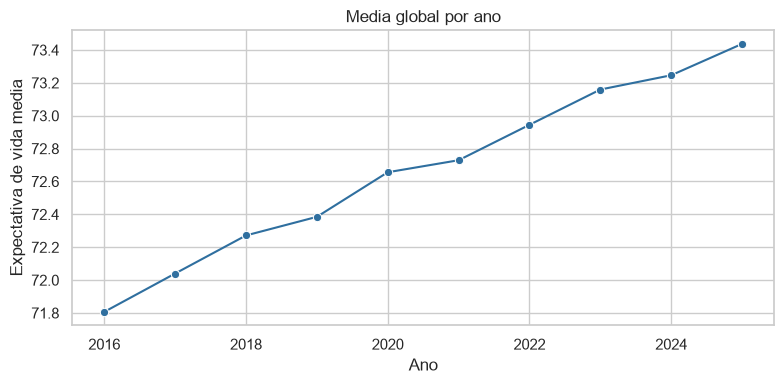

In [18]:
# Média global por ano
fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(data=year_trend, x="year", y="life_expectancy", marker="o", ax=ax, color="#2f6f9f")
ax.set_title("Media global por ano")
ax.set_xlabel("Ano")
ax.set_ylabel("Expectativa de vida media")
plt.tight_layout()
plt.show()

A serie anual acima serve como verificacao simples de tendencia. O ranking de paises ajuda a conferir se os extremos fazem sentido antes de treinar modelos.

## 4.1 Evolucao temporal por pais

In [19]:
country_year = df_clean.groupby(["country", "year"], as_index=False)["life_expectancy"].mean()

first_year = (
    country_year.sort_values("year")
    .groupby("country")
    .first()
    .rename(columns={"year": "ano_inicial", "life_expectancy": "expectativa_inicial"})
)
last_year = (
    country_year.sort_values("year")
    .groupby("country")
    .last()
    .rename(columns={"year": "ano_final", "life_expectancy": "expectativa_final"})
)

country_change = first_year.join(last_year)
country_change["delta_periodo"] = country_change["expectativa_final"] - country_change["expectativa_inicial"]
country_change = country_change.reset_index()

country_volatility = (
    country_year.groupby("country")["life_expectancy"]
    .std()
    .rename("desvio_padrao_periodo")
    .reset_index()
    .sort_values("desvio_padrao_periodo", ascending=False)
)

top_improvement = country_change.sort_values("delta_periodo", ascending=False).head(10)
top_decline = country_change.sort_values("delta_periodo").head(10)
top_volatility = country_volatility.head(10)

display(top_improvement)
display(top_decline)
display(top_volatility)

,country,ano_inicial,expectativa_inicial,ano_final,expectativa_final,delta_periodo
186,Uzbekistan,2016,70.610,2025,81.450,10.840
13,Barbados,2016,74.780,2025,84.070,9.290
52,Egypt,2016,78.470,2025,87.700,9.230
68,Guatemala,2016,71.020,2025,80.180,9.160
182,United Kingdom of Great Britain and Northern I...,2016,80.840,2025,89.150,8.310
167,Syrian Arab Republic,2016,65.030,2025,72.530,7.500
86,Kazakhstan,2016,74.080,2025,81.310,7.230
89,Kuwait,2016,75.370,2025,82.530,7.160
39,Costa Rica,2016,81.390,2025,88.500,7.110
6,Armenia,2016,74.960,2025,81.740,6.780


,country,ano_inicial,expectativa_inicial,ano_final,expectativa_final,delta_periodo
24,Bulgaria,2016,74.670,2025,67.470,-7.200
108,Mexico,2016,74.140,2024,67.770,-6.370
185,Uruguay,2016,76.870,2025,70.970,-5.900
125,Norway,2016,80.810,2025,75.410,-5.400
73,Honduras,2016,73.860,2025,68.810,-5.050
85,Jordan,2016,73.350,2025,68.950,-4.400
21,Botswana,2016,66.620,2025,62.760,-3.860
8,Austria,2016,81.680,2025,77.910,-3.770
135,Portugal,2016,81.370,2025,77.740,-3.630
22,Brazil,2016,73.740,2025,70.150,-3.590


,country,desvio_padrao_periodo
186,Uzbekistan,3.204
140,Russian Federation,2.971
89,Kuwait,2.943
52,Egypt,2.922
75,Iceland,2.880
39,Costa Rica,2.797
68,Guatemala,2.728
170,The former Yugoslav republic of Macedonia,2.696
24,Bulgaria,2.692
81,Israel,2.664


As tabelas mostram quais paises mais melhoraram, quais perderam expectativa de vida e quais tiveram maior instabilidade no periodo. Essa visao ajuda a sair da media global e encontrar casos que merecem analise individual.

## 5. Features para modelagem

In [20]:
df_feat = df_clean.copy()

for col in ["gdp", "population", "measles", "percentage_expenditure"]:
    df_feat[f"log_{col}"] = np.log1p(df_feat[col].clip(lower=0))

df_feat["vaccine_coverage_avg"] = df_feat[["hepatitis_b", "polio", "diphtheria"]].mean(axis=1)
df_feat["thinness_avg"] = df_feat[["thinness_119_years", "thinness_59_years"]].mean(axis=1)
df_feat["disease_burden"] = df_feat["hivaids"] + df_feat["measles"]
df_feat["mortality_le_ratio"] = df_feat["adult_mortality"] / df_feat["life_expectancy"]
df_feat["status_enc"] = (df_feat["status"] == "Developed").astype(int)
df_feat["year_norm"] = (df_feat["year"] - df_feat["year"].min()) / (df_feat["year"].max() - df_feat["year"].min())

selected_features = [
    "adult_mortality", "log_gdp", "schooling", "income_composition_of_resources",
    "vaccine_coverage_avg", "hivaids", "thinness_avg", "status_enc",
    "year_norm", "total_expenditure", "bmi",
]

target_col = "life_expectancy"

feature_notes = pd.DataFrame([
    ["log_gdp", "gdp", "reduzir assimetria", "sim"],
    ["log_population", "population", "reduzir assimetria", "nao"],
    ["log_measles", "measles", "reduzir assimetria", "nao"],
    ["vaccine_coverage_avg", "hepatitis_b, polio, diphtheria", "resumir cobertura vacinal", "sim"],
    ["thinness_avg", "thinness_119_years, thinness_59_years", "reduzir redundancia", "sim"],
    ["mortality_le_ratio", "adult_mortality, life_expectancy", "feature exploratoria com vazamento", "nao"],
    ["status_enc", "status", "codificar categoria", "sim"],
    ["year_norm", "year", "representar tempo", "sim"],
], columns=["feature", "origem", "motivo", "entra_no_modelo"])

display(feature_notes)
display(df_feat[[target_col] + selected_features].head())

,feature,origem,motivo,entra_no_modelo
0,log_gdp,gdp,reduzir assimetria,sim
1,log_population,population,reduzir assimetria,nao
2,log_measles,measles,reduzir assimetria,nao
3,vaccine_coverage_avg,"hepatitis_b, polio, diphtheria",resumir cobertura vacinal,sim
4,thinness_avg,"thinness_119_years, thinness_59_years",reduzir redundancia,sim
5,mortality_le_ratio,"adult_mortality, life_expectancy",feature exploratoria com vazamento,nao
6,status_enc,status,codificar categoria,sim
7,year_norm,year,representar tempo,sim


,life_expectancy,adult_mortality,log_gdp,schooling,income_composition_of_resources,vaccine_coverage_avg,hivaids,thinness_avg,status_enc,year_norm,total_expenditure,bmi
0,65.040,260,6.641,10.030,0.410,45.660,0.100,17.090,0,0.000,8.210,19.120
1,66.980,259,6.837,9.930,0.440,46.433,0.060,17.030,0,0.111,8.050,19.330
2,68.020,253,7.020,9.950,0.420,46.920,0.010,17.080,0,0.222,8.000,19.530
3,68.120,248,7.178,9.910,0.400,47.050,0.000,17.025,0,0.333,8.120,19.120
4,69.270,244,7.309,10.010,0.390,47.393,0.000,16.660,0,0.444,8.280,18.910


## 6. Correlacao e multicolinearidade

In [21]:
corr_with_target = (
    df_feat[selected_features + [target_col]]
    .corr()[target_col]
    .drop(target_col)
    .sort_values(key=lambda x: x.abs(), ascending=False)
    .to_frame("correlation_with_target")
)

x_scaled = pd.DataFrame(StandardScaler().fit_transform(df_feat[selected_features]), columns=selected_features)
x_vif = sm.add_constant(x_scaled)
vif_table = pd.DataFrame({
    "feature": x_vif.columns,
    "vif": [variance_inflation_factor(x_vif.values, i) for i in range(x_vif.shape[1])],
}).query("feature != 'const'").sort_values("vif", ascending=False)

display(corr_with_target)
display(vif_table)

,correlation_with_target
income_composition_of_resources,0.698
adult_mortality,-0.673
schooling,0.659
hivaids,-0.574
status_enc,0.489
vaccine_coverage_avg,0.473
bmi,0.467
log_gdp,0.448
thinness_avg,-0.446
total_expenditure,0.256


,feature,vif
3,schooling,2.581
4,income_composition_of_resources,2.318
1,adult_mortality,1.723
6,hivaids,1.670
11,bmi,1.610
7,thinness_avg,1.554
8,status_enc,1.491
5,vaccine_coverage_avg,1.417
2,log_gdp,1.412
10,total_expenditure,1.218


As tabelas acima mostram quais variaveis se relacionam mais com a expectativa de vida e se alguma delas tem VIF alto. Como as variaveis muito redundantes foram consolidadas, a matriz final fica mais simples para interpretar.

## 7. Regressao OLS para interpretacao

In [22]:
X_ols = pd.DataFrame(StandardScaler().fit_transform(df_feat[selected_features]), columns=selected_features)
y = df_feat[target_col]
ols_model = sm.OLS(y, sm.add_constant(X_ols)).fit()

ols_metrics = pd.DataFrame({
    "metrica": ["r2", "r2_ajustado", "pvalue_modelo", "durbin_watson", "condition_number"],
    "valor": [
        ols_model.rsquared,
        ols_model.rsquared_adj,
        ols_model.f_pvalue,
        sm.stats.stattools.durbin_watson(ols_model.resid),
        ols_model.condition_number,
    ],
})

ols_coefficients = pd.DataFrame({
    "feature": ols_model.params.index,
    "coef": ols_model.params.values,
    "pvalue": ols_model.pvalues.values,
}).query("feature != 'const'").sort_values("pvalue")

display(ols_metrics)

,metrica,valor
0,r2,0.746
1,r2_ajustado,0.744
2,pvalue_modelo,0.000
3,durbin_watson,0.374
4,condition_number,3.927


In [23]:
display(ols_coefficients)

,feature,coef,pvalue
1,adult_mortality,-2.290,0.000
4,income_composition_of_resources,2.032,0.000
6,hivaids,-1.473,0.000
5,vaccine_coverage_avg,0.924,0.000
3,schooling,1.102,0.000
7,thinness_avg,-0.813,0.000
8,status_enc,0.765,0.000
2,log_gdp,0.496,0.000
10,total_expenditure,0.397,0.000
11,bmi,0.308,0.011


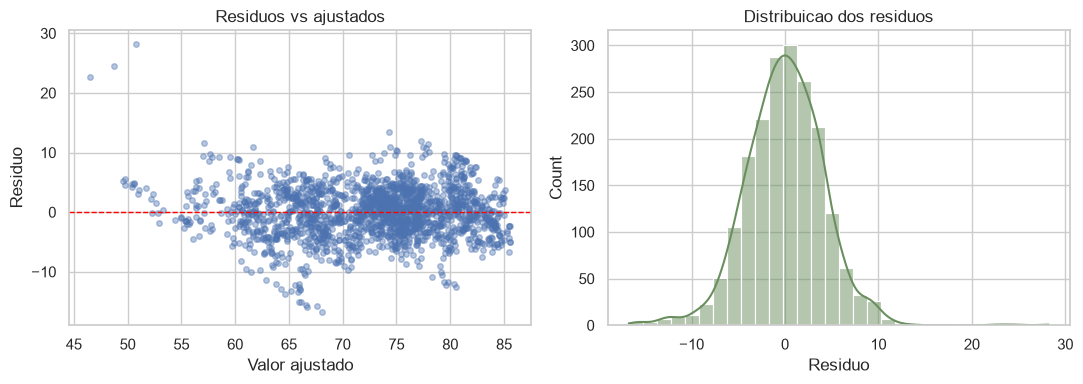

In [24]:
# Distribuição dos resíduos
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(ols_model.fittedvalues, ols_model.resid, alpha=0.4, s=16)
axes[0].axhline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Residuos vs ajustados")
axes[0].set_xlabel("Valor ajustado")
axes[0].set_ylabel("Residuo")

sns.histplot(ols_model.resid, bins=30, kde=True, ax=axes[1], color="#6a8f5f")
axes[1].set_title("Distribuicao dos residuos")
axes[1].set_xlabel("Residuo")

plt.tight_layout()
plt.show()

Os resíduos estão concentrados em torno de zero, indicando que o modelo OLS não apresenta um viés forte nas previsões. A distribuição é aproximadamente simétrica, mas há alguns valores extremos, principalmente resíduos positivos altos. No gráfico de resíduos vs. ajustados, a dispersão não é totalmente uniforme, sugerindo que o modelo linear captura a tendência geral, mas ainda deixa padrões que podem ser melhor tratados por modelos não lineares.

## 8. Modelagem preditiva

In [25]:
X = df_feat[selected_features]
y = df_feat[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

models = {
    "Linear Regression": Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())]),
    "Ridge": Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=1.0))]),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, random_state=42),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = []
fitted_models = {}

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=kf, scoring="r2", n_jobs=-1)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    results.append({
        "model": name,
        "cv_r2_mean": cv_scores.mean(),
        "test_r2": r2_score(y_test, pred),
        "test_rmse": np.sqrt(mean_squared_error(y_test, pred)),
        "test_mae": mean_absolute_error(y_test, pred),
    })
    fitted_models[name] = model

results_df = pd.DataFrame(results).sort_values("test_rmse").reset_index(drop=True)
best_model_name = results_df.loc[0, "model"]
best_model = fitted_models[best_model_name]
best_pred = best_model.predict(X_test)

display(results_df)

,model,cv_r2_mean,test_r2,test_rmse,test_mae
0,Random Forest,0.950,0.963,1.628,1.104
1,Gradient Boosting,0.932,0.942,2.050,1.544
2,Linear Regression,0.734,0.754,4.213,3.287
3,Ridge,0.734,0.754,4.213,3.287


A comparação dos modelos mostra que o **Random Forest** apresentou o melhor desempenho geral. Ele teve o maior `test_r2` (`0.963`) e os menores erros (`RMSE = 1.625` e `MAE = 1.103`), indicando previsões mais próximas dos valores reais de expectativa de vida.

O `cv_r2_mean` representa o R² médio na validação cruzada, ou seja, mede o desempenho médio do modelo em diferentes divisões do conjunto de treino. Valores mais altos indicam melhor capacidade de generalização. O `test_r2` mede a proporção da variação da expectativa de vida explicada pelo modelo no conjunto de teste. Quanto mais próximo de 1, melhor.

O `test_rmse` é a raiz do erro quadrático médio. Ele mede o erro médio em anos, penalizando mais os erros grandes. Já o `test_mae` é o erro absoluto médio, também em anos, mas menos sensível a valores extremos.

Comparando os modelos, o **Gradient Boosting** também teve bom desempenho, mas ficou abaixo do Random Forest. Já os modelos lineares, **Linear Regression** e **Ridge**, apresentaram erros bem maiores e R² menor, sugerindo que a relação entre os indicadores e a expectativa de vida não é totalmente linear.

## 8.1 Validacao temporal

In [26]:
train_temporal = df_feat[df_feat["year"] <= 2023]
test_temporal = df_feat[df_feat["year"] >= 2024]

X_train_time = train_temporal[selected_features]
y_train_time = train_temporal[target_col]
X_test_time = test_temporal[selected_features]
y_test_time = test_temporal[target_col]

temporal_results = []
for name, model in models.items():
    model_time = clone(model)
    model_time.fit(X_train_time, y_train_time)
    pred_time = model_time.predict(X_test_time)
    temporal_results.append({
        "model": name,
        "train_years": "2016-2023",
        "test_years": "2024-2025",
        "test_r2": r2_score(y_test_time, pred_time),
        "test_rmse": np.sqrt(mean_squared_error(y_test_time, pred_time)),
        "test_mae": mean_absolute_error(y_test_time, pred_time),
    })

temporal_results_df = pd.DataFrame(temporal_results).sort_values("test_rmse").reset_index(drop=True)
display(temporal_results_df)

,model,train_years,test_years,test_r2,test_rmse,test_mae
0,Random Forest,2016-2023,2024-2025,0.921,2.402,1.729
1,Gradient Boosting,2016-2023,2024-2025,0.895,2.764,2.176
2,Ridge,2016-2023,2024-2025,0.683,4.797,3.754
3,Linear Regression,2016-2023,2024-2025,0.683,4.797,3.754


A validacao temporal e mais exigente porque treina com anos anteriores e testa em anos futuros. Se o desempenho continuar bom nesse corte, o modelo mostra melhor capacidade de generalizar para previsoes fora do periodo usado no treino.

Pelo ranking acima, o melhor modelo foi escolhido pelo menor RMSE no conjunto de teste. O R2 de validacao cruzada fica na tabela para checar se o desempenho nao dependeu apenas de uma divisao favoravel dos dados.

,importance
hivaids,0.449
adult_mortality,0.267
schooling,0.076
thinness_avg,0.055
log_gdp,0.038
income_composition_of_resources,0.033
bmi,0.031
vaccine_coverage_avg,0.023
total_expenditure,0.019
status_enc,0.006


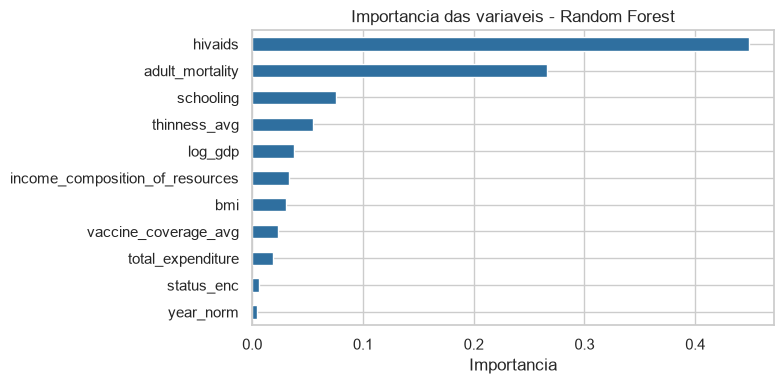

In [27]:
def get_importance(model):
    estimator = model.named_steps["model"] if isinstance(model, Pipeline) else model
    if hasattr(estimator, "feature_importances_"):
        values = estimator.feature_importances_
    else:
        values = np.abs(estimator.coef_)
    return pd.Series(values, index=selected_features).sort_values(ascending=False)

importance = get_importance(best_model)
display(importance.to_frame("importance"))

fig, ax = plt.subplots(figsize=(8, 4))
importance.sort_values().plot(kind="barh", ax=ax, color="#2f6f9f")
ax.set_title(f"Importancia das variaveis - {best_model_name}")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.show()

A importancia acima aponta quais variaveis o melhor modelo mais usou para prever expectativa de vida. Como essa importancia vem do modelo preditivo, ela deve ser lida como apoio a decisao, nao como prova causal.

## 8.2 Explicabilidade adicional

In [28]:
permutation = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring="neg_mean_absolute_error",
)

permutation_table = (
    pd.DataFrame({
        "feature": selected_features,
        "impacto_medio_no_mae": permutation.importances_mean,
        "desvio": permutation.importances_std,
    })
    .sort_values("impacto_medio_no_mae", ascending=False)
    .reset_index(drop=True)
)

display(permutation_table.head(10))

,feature,impacto_medio_no_mae,desvio
0,adult_mortality,2.652,0.124
1,hivaids,1.811,0.137
2,thinness_avg,1.124,0.044
3,schooling,0.917,0.058
4,bmi,0.772,0.048
5,log_gdp,0.549,0.037
6,vaccine_coverage_avg,0.479,0.028
7,income_composition_of_resources,0.375,0.026
8,total_expenditure,0.284,0.029
9,status_enc,0.070,0.011


A importancia por permutacao mede quanto o erro piora quando uma variavel e embaralhada. Ela complementa a importancia nativa do Random Forest e ajuda a confirmar quais variaveis sustentam a previsao.

## 9. Avaliacao do modelo escolhido

,count,mean,median,max
status,,,,
Developed,65,1.123,0.864,3.318
Developing,321,1.100,0.742,11.238


,country,year,status,real,predito,erro,erro_abs
529,Egypt,2025,Developing,87.700,76.462,-11.238,11.238
527,Egypt,2023,Developing,85.760,77.698,-8.062,8.062
526,Egypt,2022,Developing,85.250,78.419,-6.831,6.831
1920,Zimbabwe,2016,Developing,68.630,62.374,-6.256,6.256
450,Democratic People's Republic of Korea,2016,Developing,76.330,71.009,-5.321,5.321
730,Honduras,2016,Developing,73.860,68.830,-5.030,5.030
1310,Paraguay,2016,Developing,75.220,70.434,-4.786,4.786
859,Jordan,2025,Developing,68.950,73.459,4.509,4.509


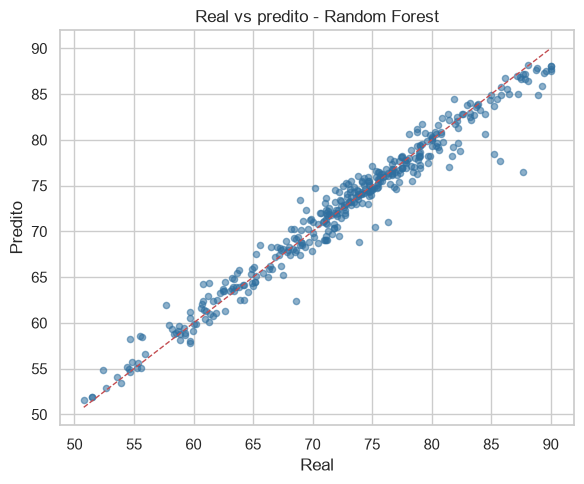

In [29]:
test_result = df_feat.loc[X_test.index, ["country", "year", "status", target_col]].copy()
test_result = test_result.rename(columns={target_col: "real"})
test_result["predito"] = best_pred
test_result["erro"] = test_result["predito"] - test_result["real"]
test_result["erro_abs"] = test_result["erro"].abs()

error_by_status = test_result.groupby("status")["erro_abs"].agg(["count", "mean", "median", "max"])
worst_errors = test_result.sort_values("erro_abs", ascending=False).head(8)

display(error_by_status)
display(worst_errors)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(test_result["real"], test_result["predito"], alpha=0.55, s=20, color="#2f6f9f")
lims = [test_result[["real", "predito"]].min().min(), test_result[["real", "predito"]].max().max()]
ax.plot(lims, lims, "r--", linewidth=1)
ax.set_title(f"Real vs predito - {best_model_name}")
ax.set_xlabel("Real")
ax.set_ylabel("Predito")
plt.tight_layout()
plt.show()

A tabela por `Status` mostra se o erro ficou concentrado em algum grupo. A lista dos maiores erros ajuda a encontrar paises/anos que poderiam merecer revisao de dado ou analise separada.

## 9.1 Analise detalhada dos erros

In [30]:
error_by_year = (
    test_result.groupby("year")["erro_abs"]
    .agg(["count", "mean", "median", "max"])
    .reset_index()
)

test_result["faixa_expectativa"] = pd.cut(
    test_result["real"],
    bins=[0, 60, 70, 80, 100],
    labels=["ate_60", "60_70", "70_80", "80_mais"],
)
error_by_range = (
    test_result.groupby("faixa_expectativa", observed=True)["erro_abs"]
    .agg(["count", "mean", "median", "max"])
    .reset_index()
)

error_by_country = (
    test_result.groupby("country")["erro_abs"]
    .agg(["count", "mean", "max"])
    .query("count >= 2")
    .sort_values("mean", ascending=False)
    .head(10)
    .reset_index()
)

display(error_by_year)
display(error_by_range)
display(error_by_country)

,year,count,mean,median,max
0,2016,45,1.337,0.865,6.256
1,2017,31,0.820,0.657,2.784
2,2018,40,0.796,0.597,2.545
3,2019,36,0.742,0.584,2.484
4,2020,46,1.042,0.676,4.249
5,2021,42,1.046,1.026,3.524
6,2022,38,1.139,0.683,6.831
7,2023,38,1.086,0.745,8.062
8,2024,32,0.982,0.734,4.496
9,2025,38,1.954,1.584,11.238


,faixa_expectativa,count,mean,median,max
0,ate_60,35,1.056,0.680,4.249
1,60_70,92,1.091,0.853,6.256
2,70_80,188,0.960,0.667,5.321
3,80_mais,71,1.526,0.966,11.238


,country,count,mean,max
0,Egypt,3,8.710,11.238
1,Jordan,2,3.694,4.509
2,Democratic People's Republic of Korea,2,2.680,5.321
3,Israel,2,2.518,4.061
4,Honduras,3,2.438,5.030
5,Indonesia,2,2.437,2.677
6,Zimbabwe,3,2.305,6.256
7,Namibia,2,2.261,2.907
8,Argentina,2,2.231,3.574
9,Republic of Korea,2,2.019,3.822


A analise dos erros mostra onde o modelo precisa de mais cuidado: por ano, por faixa de expectativa de vida e por pais. Isso ajuda a transformar uma metrica geral boa em uma avaliacao mais util para negocio.

## 10. Previsao e cenarios

In [31]:
base_case = pd.DataFrame([{
    "adult_mortality": 145,
    "log_gdp": np.log1p(4200),
    "schooling": 11.5,
    "income_composition_of_resources": 0.62,
    "vaccine_coverage_avg": 82.0,
    "hivaids": 0.4,
    "thinness_avg": 6.5,
    "status_enc": 0,
    "year_norm": (2027 - df_clean["year"].min()) / (df_clean["year"].max() - df_clean["year"].min()),
    "total_expenditure": 6.1,
    "bmi": 24.5,
}])[selected_features]

scenarios = {
    "base_2027": base_case.iloc[0].copy(),
    "mortalidade_adulta_menos_10pct": base_case.iloc[0].copy(),
    "cobertura_vacinal_90": base_case.iloc[0].copy(),
    "escolaridade_mais_1_ano": base_case.iloc[0].copy(),
    "hivaids_0_1": base_case.iloc[0].copy(),
    "pacote_integrado": base_case.iloc[0].copy(),
}

scenarios["mortalidade_adulta_menos_10pct"]["adult_mortality"] *= 0.90
scenarios["cobertura_vacinal_90"]["vaccine_coverage_avg"] = 90.0
scenarios["escolaridade_mais_1_ano"]["schooling"] += 1.0
scenarios["hivaids_0_1"]["hivaids"] = 0.1

scenarios["pacote_integrado"]["adult_mortality"] *= 0.90
scenarios["pacote_integrado"]["vaccine_coverage_avg"] = 90.0
scenarios["pacote_integrado"]["schooling"] += 1.0
scenarios["pacote_integrado"]["hivaids"] = 0.1

scenario_df = pd.DataFrame(scenarios).T[selected_features]
scenario_result = scenario_df[["adult_mortality", "vaccine_coverage_avg", "schooling", "hivaids"]].copy()
scenario_result["previsao"] = best_model.predict(scenario_df)
scenario_result["delta_vs_base"] = scenario_result["previsao"] - scenario_result.loc["base_2027", "previsao"]
scenario_result = scenario_result.sort_values("previsao", ascending=False)

n_bootstrap = 80
bootstrap_preds = []
for seed in range(n_bootstrap):
    X_bs, y_bs = resample(X_train, y_train, random_state=seed)
    model_bs = clone(best_model)
    model_bs.fit(X_bs, y_bs)
    bootstrap_preds.append(model_bs.predict(base_case)[0])

interval = pd.DataFrame({
    "cenario": ["base_2027"],
    "previsao": [scenario_result.loc["base_2027", "previsao"]],
    "ic_2_5": [np.percentile(bootstrap_preds, 2.5)],
    "ic_97_5": [np.percentile(bootstrap_preds, 97.5)],
})

display(scenario_result)
display(interval)

,adult_mortality,vaccine_coverage_avg,schooling,hivaids,previsao,delta_vs_base
pacote_integrado,130.500,90.000,12.500,0.100,74.713,7.037
hivaids_0_1,145.000,82.000,11.500,0.100,69.272,1.596
cobertura_vacinal_90,145.000,90.000,11.500,0.400,69.020,1.344
mortalidade_adulta_menos_10pct,130.500,82.000,11.500,0.400,68.042,0.366
escolaridade_mais_1_ano,145.000,82.000,12.500,0.400,67.952,0.276
base_2027,145.000,82.000,11.500,0.400,67.676,0.000


,cenario,previsao,ic_2_5,ic_97_5
0,base_2027,67.676,65.045,70.710


Os cenarios agora comparam acoes mais proximas de decisoes publicas: reducao de mortalidade adulta, aumento de cobertura vacinal, ganho de escolaridade e reducao de HIV/AIDS. A priorizacao considera o maior `delta_vs_base`, mas a escolha final tambem depende de custo, prazo e viabilidade de implementacao.

## 11. Fechamento

In [32]:
final_summary = pd.DataFrame({
    "item": [
        "modelo_escolhido",
        "rmse_teste",
        "mae_teste",
        "r2_teste",
        "r2_validacao_temporal",
        "principal_variavel",
        "melhor_cenario",
    ],
    "valor": [
        best_model_name,
        results_df.loc[0, "test_rmse"],
        results_df.loc[0, "test_mae"],
        results_df.loc[0, "test_r2"],
        temporal_results_df.loc[temporal_results_df["model"] == best_model_name, "test_r2"].iloc[0],
        importance.index[0],
        scenario_result.drop(index="base_2027").sort_values("delta_vs_base", ascending=False).index[0],
    ],
})

display(final_summary)

,item,valor
0,modelo_escolhido,Random Forest
1,rmse_teste,1.628
2,mae_teste,1.104
3,r2_teste,0.963
4,r2_validacao_temporal,0.921
5,principal_variavel,hivaids
6,melhor_cenario,pacote_integrado


O resumo acima fecha o caminho do notebook: os dados foram limpos, o modelo foi escolhido por desempenho em teste, as variaveis principais foram inspecionadas e os cenarios foram comparados com a mesma estrutura de entrada.